
# 04 — Signal Digger Checklist (robust)

This notebook provides a practical checklist for evaluating and validating trading signals before using them in backtests or models. It helps you explore the data behind each signal, check its structure and coverage, and run quick diagnostics on performance and correlations.  

Use it as a guide to ensure your signals are properly cleaned, aligned, and statistically sound before moving forward with deeper factor analysis or portfolio construction.

**Outputs**
- `model_ready.csv` (final curated features + `target`)
- `final_features.json` (exact column list)
- `factor_scores.csv`, `regime_ic.csv`, `feature_clusters.json`



In [28]:

import os

# ==== Paths (EDIT these) ====
ROOT = r"C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory"
FEATURES_CSV = fr"{ROOT}\outputs\features\selected_features.csv"
TRAIN_CSV    = fr"{ROOT}\data\processed\sp500.csv"
TEST_CSV     = fr"{ROOT}\data\test.csv"
TARGET_CSV   = fr"{ROOT}\data\factor_plus\forward_returns.csv"
SCORED_CSV   = None

# ==== Outputs ====
OUT_DIR      = fr"{ROOT}\outputs\signal_digger"
MODEL_READY  = os.path.join(OUT_DIR, "model_ready.csv")
FACTOR_SCORES_CSV = os.path.join(OUT_DIR, "factor_scores.csv")
REGIME_IC_CSV     = os.path.join(OUT_DIR, "regime_ic.csv")
CLUSTERS_JSON     = os.path.join(OUT_DIR, "feature_clusters.json")
FINAL_FEATURES_JSON = os.path.join(OUT_DIR, "final_features.json")

# ==== Knobs ====
ROLLING_WINDOW   = 63
MAX_FEATURES     = 40
CORR_THRESHOLD   = 0.85
N_PLOT           = 6
N_BOOT           = 100
SAMPLE_FRAC      = 0.75
LASSO_PROB_TH    = 0.50
NAN_COL_THRESH   = 0.50
WARMUP_MIN       = 60
WARMUP_MAX_CAP   = 180
ALPHA_GRID       = None

os.makedirs(OUT_DIR, exist_ok=True)
print("Outputs ->", OUT_DIR)


Outputs -> C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\signal_digger


In [39]:
SP500_CSV = r"C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\data\processed\SP500.csv"
TARGET_CSV = r"C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\factor_plus\forward_returns.csv"

import os, pandas as pd, numpy as np

sp = pd.read_csv(SP500_CSV, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

# 1) Prefer an existing return column
if "market_forward_excess_returns" in sp.columns:
    sp["forward_returns"] = sp["market_forward_excess_returns"]
else:
    # 2) Else compute from a price column (pick the first that exists)
    price_col = next(
        (c for c in ["close","adj_close","Close","Adj Close","price","M1","PX_LAST"] if c in sp.columns),
        None
    )
    if price_col is None:
        raise ValueError("SP500.csv has neither a return column nor a recognizable price column.")
    sp[price_col] = pd.to_numeric(sp[price_col], errors="coerce")
    sp["forward_returns"] = np.log(sp[price_col].shift(-1) / sp[price_col])

out = sp[["date","forward_returns"]].dropna().copy()
os.makedirs(os.path.dirname(TARGET_CSV), exist_ok=True)
out.to_csv(TARGET_CSV, index=False)
print("✅ Wrote", TARGET_CSV, "rows:", len(out))
print(out.head())


✅ Wrote C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\factor_plus\forward_returns.csv rows: 8990
        date  forward_returns
0 1990-01-01        -0.003038
1 1990-01-02        -0.009114
2 1990-01-03        -0.010243
3 1990-01-04         0.004046
4 1990-01-05        -0.012301


Saved: C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\signal_digger\factor_scores.csv


c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,feature,mean_ic,std_ic,icir,sign_flips,score
0,ROLL_MAX_M1_W120,NaN,NaN,NaN,0.084778,NaN
1,market_forward_excess_returns,0.999998,0.000005,3.198425e+06,0.000000,0.999995
2,ROLL_MAX_M1_W5,0.145584,0.106260,2.174928e+01,0.031991,0.084457
3,ZSCORE_M1_W120,0.117281,0.117891,1.579241e+01,0.044158,0.047296
4,ROLL_STD_M1_W10,0.084267,0.122359,1.093261e+01,0.043311,0.012260
5,ROLL_STD_M1_W5,0.068432,0.116244,9.345197e+00,0.043246,-0.000502
6,ROLL_STD_M1_W20,0.056507,0.119153,7.528263e+00,0.063672,-0.018988
7,TECH_BB_POSITION_M1,0.047655,0.129517,5.840972e+00,0.051770,-0.030046
8,DIFF_M1_SUB_M2,0.036544,0.120292,4.822605e+00,0.058284,-0.038173
9,ROLL_STD_M1_W60,0.044572,0.146797,4.820005e+00,0.071063,-0.046592


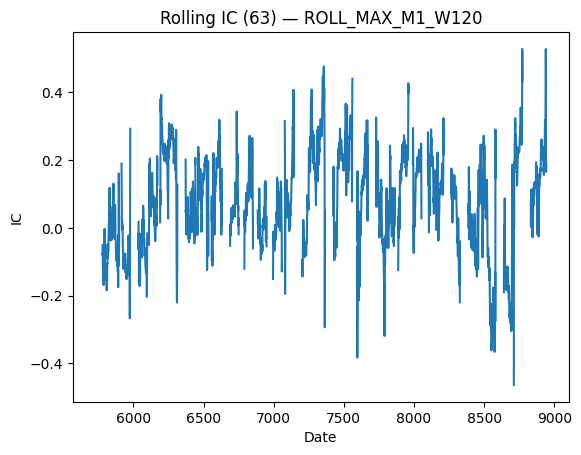

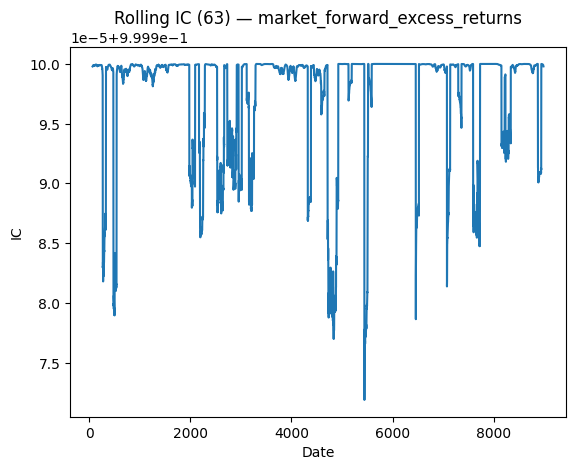

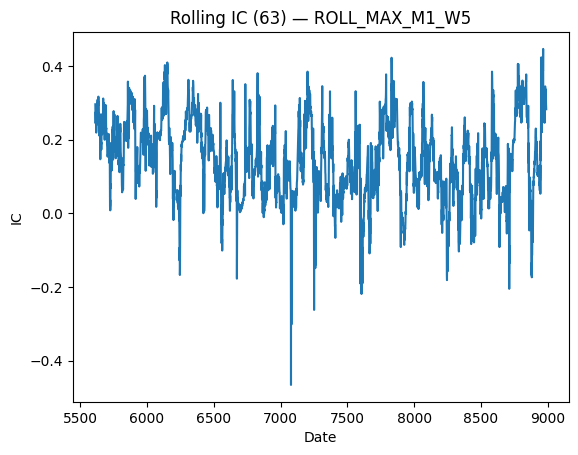

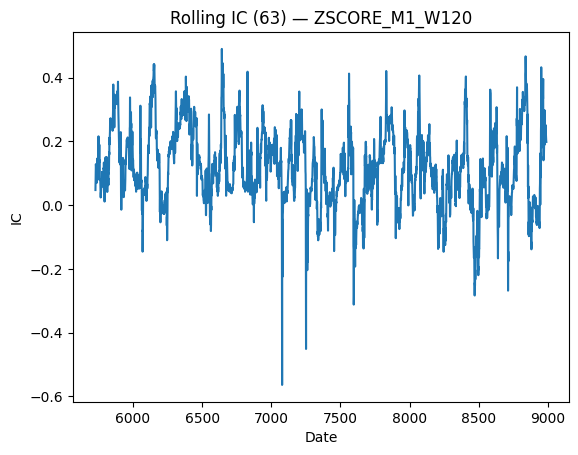

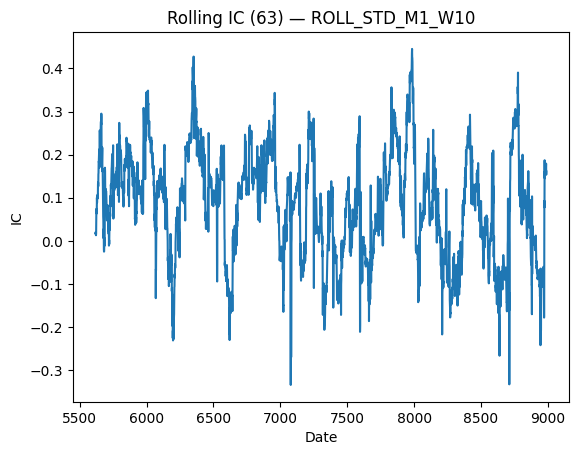

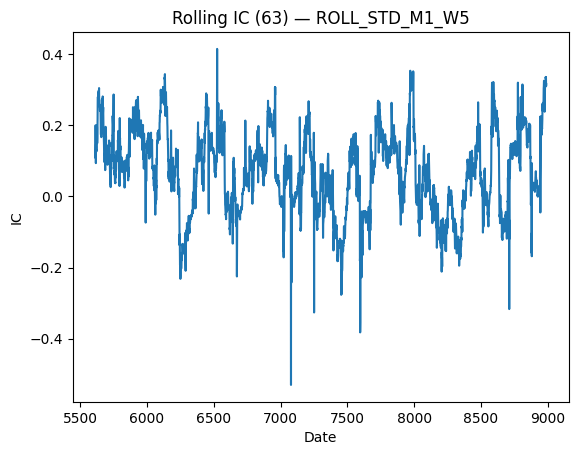

In [40]:

scores = fl.compute_stability_scores(X, y, window=ROLLING_WINDOW)
scores_df = pd.DataFrame([s.__dict__ for s in scores])
scores_df.to_csv(FACTOR_SCORES_CSV, index=False)
print("Saved:", FACTOR_SCORES_CSV)
display(scores_df.head(20))

to_plot = [s.feature for s in scores[:N_PLOT]]
for f in to_plot:
    ic_roll = fl.rolling_ic(X[f], y, window=ROLLING_WINDOW)
    plt.figure()
    ic_roll.plot(title=f"Rolling IC ({ROLLING_WINDOW}) — {f}")
    plt.xlabel("Date"); plt.ylabel("IC")
    plt.show()


In [41]:

pool = [s.feature for s in scores[:max(100, MAX_FEATURES*3)]]
pre_na = X[pool].isna().mean().sort_values(ascending=False)
drop_pre = pre_na[pre_na > 0.95].index.tolist()
if drop_pre:
    print("Dropping pre-cluster ~all-NaN:", drop_pre[:10], "…")
    pool = [c for c in pool if c not in drop_pre]

clusters, reps = fl.corr_cluster(X[pool].fillna(method="ffill").fillna(method="bfill"), threshold=CORR_THRESHOLD)
with open(CLUSTERS_JSON, "w", encoding="utf-8") as f:
    json.dump(clusters, f, indent=2)
print("Saved clusters:", CLUSTERS_JSON)
print("Clusters:", len(clusters), "Representatives:", len(reps))

selected_by_cluster = reps[:max(MAX_FEATURES*2, 30)]
print("Initial reps kept:", len(selected_by_cluster))


Saved clusters: C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\signal_digger\feature_clusters.json
Clusters: 20 Representatives: 20
Initial reps kept: 20


C:\Users\Tianyi Zhang\AppData\Local\Temp\ipykernel_5428\978284912.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  clusters, reps = fl.corr_cluster(X[pool].fillna(method="ffill").fillna(method="bfill"), threshold=CORR_THRESHOLD)


In [42]:

rv = fl.realized_vol(y, span=30)
regimes = fl.regime_labels(rv)
reg_table = fl.regime_ic_table(X[selected_by_cluster], y, regimes, window=ROLLING_WINDOW)
reg_table.to_csv(REGIME_IC_CSV)
print("Saved:", REGIME_IC_CSV)
display(reg_table.head(20))

keep_regime = []
for f in reg_table.index:
    vals = reg_table.loc[f].dropna().values
    if (vals > 0).sum() >= 2:
        keep_regime.append(f)

print("Regime-kept:", len(keep_regime))
candidate_set = keep_regime if len(keep_regime) >= MAX_FEATURES//2 else selected_by_cluster
print("Candidate set:", len(candidate_set))


Saved: C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\signal_digger\regime_ic.csv


c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


regime,high_vol,low_vol,mid_vol
feature,,,
DIFF_M1_SUB_M2,0.012668,-0.003312,0.081382
MOM_M1_T20,-0.056974,-0.010865,-0.033246
MOM_M1_T5,-0.017027,-0.033163,-0.023330
MOM_M1_T60,0.032370,-0.013532,-0.088790
MOM_S1_T20,0.017346,-0.033483,0.022705
RATIO_M1_DIV_M2,-0.030611,0.010361,0.006718
RATIO_M1_DIV_M3,0.017327,-0.022077,0.023494
ROLL_MAX_M1_W120,NaN,NaN,NaN
ROLL_STD_M1_W10,0.040388,0.090268,0.091440


Regime-kept: 12
Candidate set: 20


In [43]:

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, ElasticNetCV, Ridge
import numpy as np
import re

max_win = 0
for c in candidate_set:
    for pat in (r"_W(\d+)", r"_T(\d+)"):
        m = re.search(pat, c)
        if m:
            max_win = max(max_win, int(m.group(1)))
DROP_HEAD = max(WARMUP_MIN, max_win)
DROP_HEAD = min(DROP_HEAD, WARMUP_MAX_CAP)
print("Warm-up rows dropped:", DROP_HEAD)

X2 = X.iloc[DROP_HEAD:].replace([np.inf, -np.inf], np.nan)
y2 = y.iloc[DROP_HEAD:].copy()

na_ratio = X2[candidate_set].isna().mean().sort_values(ascending=False)
bad_cols = na_ratio[na_ratio > NAN_COL_THRESH].index.tolist()
if bad_cols:
    print("Dropping high-NaN columns:", bad_cols[:10], "…")
cand = [c for c in candidate_set if c not in bad_cols]

X2_part = X2[cand].ffill().bfill()
imp = SimpleImputer(strategy="median")
X2_imp = pd.DataFrame(imp.fit_transform(X2_part), index=X2_part.index, columns=cand)

scaler = StandardScaler()
X2_std = pd.DataFrame(scaler.fit_transform(X2_imp), index=X2_imp.index, columns=cand)

if X2_std.shape[1] < max(10, MAX_FEATURES//2):
    widen = [c for c in selected_by_cluster if c not in cand]
    widen = widen[: max(0, max(10, MAX_FEATURES) - X2_std.shape[1])]
    if widen:
        X2_more = X.iloc[DROP_HEAD:][widen].ffill().bfill()
        X2_more = pd.DataFrame(imp.fit_transform(X2_more), index=X2_more.index, columns=widen)
        X2_more = pd.DataFrame(scaler.fit_transform(X2_more), index=X2_more.index, columns=widen)
        X2_std = pd.concat([X2_std, X2_more], axis=1)
        cand = list(X2_std.columns)
        print("Widened candidate set to:", len(cand))

print("Cleaned matrix:", X2_std.shape)

if ALPHA_GRID is None:
    alpha_grid = np.logspace(-6, 0, 60)
else:
    alpha_grid = ALPHA_GRID

from numpy.random import default_rng
rng = default_rng(42)

# Lasso stability
counts = pd.Series(0.0, index=X2_std.columns)
for b in range(N_BOOT):
    idx = rng.choice(np.arange(len(X2_std)), size=int(len(X2_std) * SAMPLE_FRAC), replace=False)
    m = LassoCV(alphas=alpha_grid, cv=3, random_state=42)
    m.fit(X2_std.iloc[idx], y2.iloc[idx])
    sel = (np.abs(m.coef_) > 1e-8)
    counts.loc[X2_std.columns[sel]] += 1
lasso_probs = counts / N_BOOT

# ElasticNet stability
counts_en = pd.Series(0.0, index=X2_std.columns)
enet = ElasticNetCV(l1_ratio=(0.05,0.1,0.2,0.3,0.5), alphas=alpha_grid, cv=3, random_state=42)
for b in range(N_BOOT//2):
    idx = rng.choice(np.arange(len(X2_std)), size=int(len(X2_std) * SAMPLE_FRAC), replace=False)
    enet.fit(X2_std.iloc[idx], y2.iloc[idx])
    sel_en = (np.abs(enet.coef_) > 1e-8)
    counts_en.loc[X2_std.columns[sel_en]] += 1
enet_probs = counts_en / (N_BOOT//2)

print("Lasso stable ≥{:.0%}: {}".format(LASSO_PROB_TH, int((lasso_probs>=LASSO_PROB_TH).sum())))
print("ENet  stable ≥{:.0%}: {}".format(LASSO_PROB_TH, int((enet_probs >=LASSO_PROB_TH).sum())))

# Permutation importance on Ridge (last 20% val)
ridge = Ridge(alpha=1.0).fit(X2_std.iloc[:-int(len(X2_std)*0.2)], y2.iloc[:-int(len(X2_std)*0.2)])
def sharpe_like(y_true, y_pred):
    pnl = y_true * y_pred
    return float(pnl.mean() / (pnl.std(ddof=0) + 1e-12))

val_slice = slice(int(len(X2_std)*0.8), None)
base = sharpe_like(y2.iloc[val_slice], ridge.predict(X2_std.iloc[val_slice]))
perm_drop = {}
for c in X2_std.columns:
    Xp = X2_std.copy()
    Xp.loc[X2_std.index[val_slice], c] = np.random.permutation(Xp.loc[X2_std.index[val_slice], c].values)
    perm_drop[c] = base - sharpe_like(y2.iloc[val_slice], ridge.predict(Xp.iloc[val_slice]))
perm_keep = [c for c, d in perm_drop.items() if d > 0]

# Compose final set
candidates_ranked = [s.feature for s in scores if s.feature in cand]
selected = []
for f in candidates_ranked:
    if f in perm_keep or lasso_probs.get(f,0) >= LASSO_PROB_TH or enet_probs.get(f,0) >= LASSO_PROB_TH:
        selected.append(f)
    if len(selected) >= MAX_FEATURES:
        break

if len(selected) < MAX_FEATURES:
    for f in candidates_ranked:
        if f not in selected:
            selected.append(f)
        if len(selected) >= MAX_FEATURES:
            break

print("Final selected (pre-export):", len(selected))


Warm-up rows dropped: 120
Dropping high-NaN columns: ['ROLL_MAX_M1_W120', 'ROLL_STD_M1_W120', 'ZSCORE_M1_W120', 'MOM_M1_T60', 'ROLL_STD_M1_W60', 'MOM_M1_T20', 'ROLL_STD_M1_W20', 'TECH_BB_POSITION_M1', 'ROLL_STD_M1_W10', 'MOM_M1_T5'] …
Widened candidate set to: 20
Cleaned matrix: (8870, 20)
Lasso stable ≥50%: 11
ENet  stable ≥50%: 18
Final selected (pre-export): 20


In [44]:

# Export model_ready + features
from sklearn.impute import SimpleImputer
imp2 = SimpleImputer(strategy="median")

X_final = X[selected].copy().ffill().bfill()
X_final = pd.DataFrame(imp2.fit_transform(X_final), index=X_final.index, columns=X_final.columns)

df_model = pd.concat([X_final, y.rename("target")], axis=1).dropna(subset=["target"])
df_model.to_csv(MODEL_READY, index=True)
with open(FINAL_FEATURES_JSON, "w", encoding="utf-8") as f:
    json.dump(selected, f, indent=2)

print("Saved model_ready:", MODEL_READY)
print("Saved final_features.json:", FINAL_FEATURES_JSON)
display(df_model.head())


Saved model_ready: C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\signal_digger\model_ready.csv
Saved final_features.json: C:\Users\Tianyi Zhang\Downloads\hull-tactical-market-prediction-main\FeatureFactory\outputs\signal_digger\final_features.json


,ROLL_MAX_M1_W120,market_forward_excess_returns,ZSCORE_M1_W120,ROLL_STD_M1_W10,ROLL_STD_M1_W5,ROLL_STD_M1_W20,TECH_BB_POSITION_M1,DIFF_M1_SUB_M2,ROLL_STD_M1_W60,ROLL_STD_M1_W120,...,MOM_S1_T20,RATIO_M1_DIV_M2,TECH_ROC_S1_10,ROLL_STD_V1_W60,ZSCORE_V1_W60,MOM_M1_T5,MOM_M1_T60,MOM_M1_T20,TECH_MACD_M1,target
date_id,,,,,,,,,,,,,,,,,,,,,
0,1.639695,-0.003038,0.023528,0.12523,0.158613,0.192433,-0.615303,2.938627,0.407889,0.396891,...,-0.119023,-1.26234,0.040034,0.0,7.616867,-0.192268,-1.069959,-0.3968,0.0,-0.002421
1,1.639695,-0.009114,0.023528,0.12523,0.158613,0.192433,-0.615303,2.938627,0.407889,0.396891,...,-0.119023,-1.26234,0.040034,0.0,7.616867,-0.192268,-1.069959,-0.3968,0.0,-0.008495
2,1.639695,-0.010243,0.023528,0.12523,0.158613,0.192433,-0.615303,2.938627,0.407889,0.396891,...,-0.119023,-1.26234,0.040034,0.0,7.616867,-0.192268,-1.069959,-0.3968,0.0,-0.009624
3,1.639695,0.004046,0.023528,0.12523,0.158613,0.192433,-0.615303,2.938627,0.407889,0.396891,...,-0.119023,-1.26234,0.040034,0.0,7.616867,-0.192268,-1.069959,-0.3968,0.0,0.004662
4,1.639695,-0.012301,0.023528,0.12523,0.158613,0.192433,-0.615303,2.938627,0.407889,0.396891,...,-0.119023,-1.26234,0.040034,0.0,7.616867,-0.192268,-1.069959,-0.3968,0.0,-0.011686



## Test alignment helper + simple inference (optional)


In [45]:

import json
with open(FINAL_FEATURES_JSON, "r", encoding="utf-8") as f:
    final_features = json.load(f)

raw_test = pd.read_csv(TEST_CSV)
meta_cols = {"date_id","is_scored","lagged_forward_returns","lagged_risk_free_rate","lagged_market_forward_excess_returns"}
X_test = pd.DataFrame(index=raw_test.index, columns=final_features, dtype=float)
for c in final_features:
    X_test[c] = pd.to_numeric(raw_test[c], errors="coerce") if c in raw_test.columns else 0.0

from sklearn.impute import SimpleImputer
imp_test = SimpleImputer(strategy="median")
X_test = pd.DataFrame(imp_test.fit_transform(X_test), index=X_test.index, columns=final_features)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
import numpy as np

X_train = df_model.drop(columns=["target"]).values
y_train = df_model["target"].values

pipe = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
pipe.fit(X_train, y_train)
y_hat = pipe.predict(X_test.values)

exposure = np.clip(y_hat * 50.0, 0.0, 2.0)
submission_preview = pd.DataFrame({"date_id": raw_test["date_id"], "exposure": exposure})
display(submission_preview.head())


,date_id,exposure
0,8980,0.01998
1,8981,0.01998
2,8982,0.01998
3,8983,0.01998
4,8984,0.01998


In [46]:
print(y_hat.min(), y_hat.max(), y_hat.std())


0.00039959603983225864 0.00039959603983225864 0.0
